# 1. Load and refine the dataset

In [99]:
import pandas as pd

df = pd.read_csv("goemotions.csv")

# Display column names and sample data
print("Columns:", df.columns.tolist())
print("\nData:")
print(df.head())

Columns: ['Unnamed: 0', 'text', 'id', 'example_very_unclear', 'amusement', 'anger', 'confusion', 'disappointment', 'gratitude', 'joy', 'love', 'sadness', 'surprise', 'neutral']

Data:
   Unnamed: 0                                               text       id  \
0           0  Worst ending ever! I won't spoil it but this o...  eee021b   
1           2  Was he rejected because of his methodology or ...  ee1h5v1   
2           3                                    thanks, I agree  eemi935   
3           4                    Why would you doubt it dumbass?  eduun99   
4           5  Just take them and get them vaccinated without...  eexcq19   

   example_very_unclear  amusement  anger  confusion  disappointment  \
0                 False          0      0          0               1   
1                 False          0      0          1               0   
2                 False          0      0          0               0   
3                 False          0      1          0             

### 1.1 Drop unused columns

In [100]:
cols_to_drop = ["Unnamed: 0","id", "example_very_unclear"]

# Drop columns
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

df.head()

,text,amusement,anger,confusion,disappointment,gratitude,joy,love,sadness,surprise,neutral
0,Worst ending ever! I won't spoil it but this o...,0,0,0,1,0,0,0,0,0,0
1,Was he rejected because of his methodology or ...,0,0,1,0,0,0,0,0,0,0
2,"thanks, I agree",0,0,0,0,1,0,0,0,0,0
3,Why would you doubt it dumbass?,0,1,0,0,0,0,0,0,0,0
4,Just take them and get them vaccinated without...,0,0,0,0,0,0,0,0,0,1


In [101]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41568 entries, 0 to 41567
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            41568 non-null  object
 1   amusement       41568 non-null  int64 
 2   anger           41568 non-null  int64 
 3   confusion       41568 non-null  int64 
 4   disappointment  41568 non-null  int64 
 5   gratitude       41568 non-null  int64 
 6   joy             41568 non-null  int64 
 7   love            41568 non-null  int64 
 8   sadness         41568 non-null  int64 
 9   surprise        41568 non-null  int64 
 10  neutral         41568 non-null  int64 
dtypes: int64(10), object(1)
memory usage: 3.5+ MB
None


In [102]:
print(df.isnull().sum())

text              0
amusement         0
anger             0
confusion         0
disappointment    0
gratitude         0
joy               0
love              0
sadness           0
surprise          0
neutral           0
dtype: int64


In [103]:
df.shape

(41568, 11)

### 1.2 Convert emotion column to numeric label

In [104]:
emotions = [
    "amusement", "anger", "confusion", "disappointment", "gratitude",
    "joy", "love", "sadness", "surprise", "neutral"
]

emotion_to_label = {
    "amusement": 0,
    "anger": 1,
    "confusion": 2,
    "disappointment": 3,
    "gratitude": 4,
    "joy": 5,
    "love": 6,
    "sadness": 7,
    "surprise": 8,
    "neutral": 9
}

def get_numeric_label(row):
    for col in emotions:
        if row[col] == 1:
            return emotion_to_label[col]
    return 9

df["label"] = df[emotions].apply(get_numeric_label, axis=1)

# Drop binary emotion columns
df = df.drop(columns=emotions, errors="ignore")

print(df.head())

                                                text  label
0  Worst ending ever! I won't spoil it but this o...      3
1  Was he rejected because of his methodology or ...      2
2                                    thanks, I agree      4
3                    Why would you doubt it dumbass?      1
4  Just take them and get them vaccinated without...      9


# 2. Data Cleaning

In [105]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english")) - {"not", "no"}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+|\#\w+", "", text)
    text = re.sub(r"[^\w\s!?]", "", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)
print(df.head())

                                                text  label  \
0  Worst ending ever! I won't spoil it but this o...      3   
1  Was he rejected because of his methodology or ...      2   
2                                    thanks, I agree      4   
3                    Why would you doubt it dumbass?      1   
4  Just take them and get them vaccinated without...      9   

                                          clean_text  
0  worst ending ever ! wont spoil one sucked wors...  
1               rejected methodology content study ?  
2                                       thanks agree  
3                              would doubt dumbass ?  
4  take get vaccinated without knowledge one pare...  


# 3. Exploratory Data Analysis

### 3.1 Distribution of emotion labels

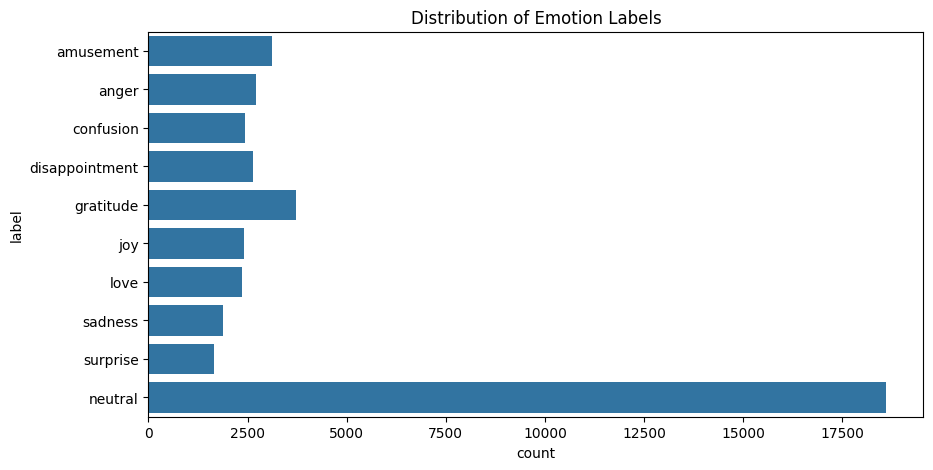

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(y="label", data=df)
plt.yticks(ticks=range(10), labels=emotions)
plt.title("Distribution of Emotion Labels")
plt.show()

### 3.2 Comment length distribution

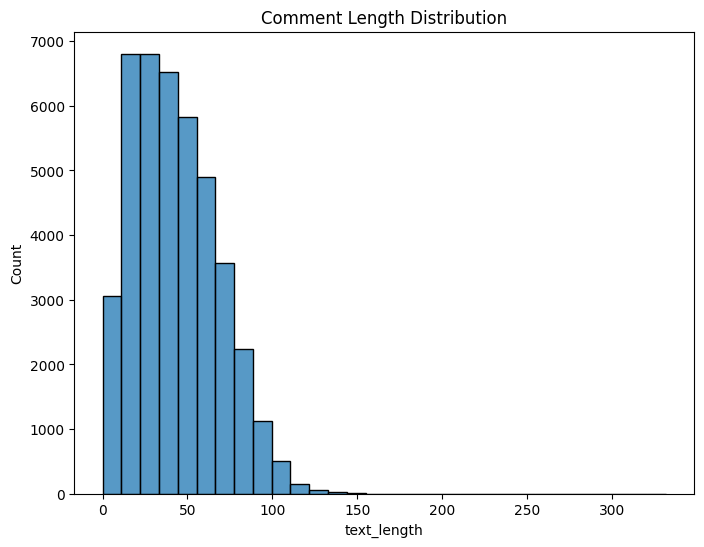

In [107]:
df["text_length"] = df["clean_text"].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(df["text_length"], bins=30)
plt.title("Comment Length Distribution")
plt.show()

# 4. Data Analysis

In [108]:
# Word frequency of particlar label
from collections import Counter

for label, emotion in emotion_to_label.items():
    texts = df[df["label"] == emotion]["clean_text"]
    words = Counter(" ".join(texts).split())
    print(f"{label}: {words.most_common(5)}")

amusement: [('lol', 1053), ('!', 633), ('name', 520), ('haha', 314), ('?', 276)]
anger: [('!', 553), ('name', 479), ('?', 378), ('fuck', 254), ('not', 241)]
confusion: [('?', 1329), ('name', 459), ('not', 443), ('dont', 331), ('im', 247)]
disappointment: [('name', 457), ('not', 304), ('!', 270), ('im', 253), ('like', 197)]
gratitude: [('!', 1853), ('thanks', 1510), ('thank', 1251), ('name', 421), ('im', 367)]
joy: [('!', 874), ('im', 363), ('happy', 352), ('name', 349), ('glad', 282)]
love: [('love', 1527), ('!', 709), ('name', 610), ('like', 390), ('one', 152)]
sadness: [('im', 285), ('name', 266), ('sorry', 242), ('sad', 220), ('!', 200)]
surprise: [('!', 557), ('?', 377), ('name', 325), ('wow', 230), ('im', 147)]
neutral: [('name', 4085), ('!', 2812), ('?', 2089), ('not', 1750), ('like', 1365)]


# 5. Train and test the model


### 5.1 Import the dependencies

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

### 5.2 Train test split

In [110]:
X = df["clean_text"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 5.3 Vectorize the data

In [111]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

### 5.4 Model training

In [112]:
model = LogisticRegression(max_iter=1000, multi_class="multinomial", class_weight="balanced")
model.fit(X_train_vec, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

### 5.5 Model testing

In [113]:
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Accuracy: 0.49338465239355306

Classification Report:
                    precision    recall  f1-score   support

     amusement (0)       0.64      0.67      0.65       624
         anger (1)       0.34      0.49      0.40       542
     confusion (2)       0.23      0.45      0.30       487
disappointment (3)       0.18      0.27      0.21       528
     gratitude (4)       0.86      0.78      0.82       743
           joy (5)       0.39      0.48      0.43       483
          love (6)       0.58      0.74      0.65       474
       sadness (7)       0.33      0.54      0.41       378
      surprise (8)       0.32      0.57      0.41       332
       neutral (9)       0.74      0.40      0.52      3723

          accuracy                           0.49      8314
         macro avg       0.46      0.54      0.48      8314
      weighted avg       0.59      0.49      0.51      8314



### 5.6. Plotting confusion matrix

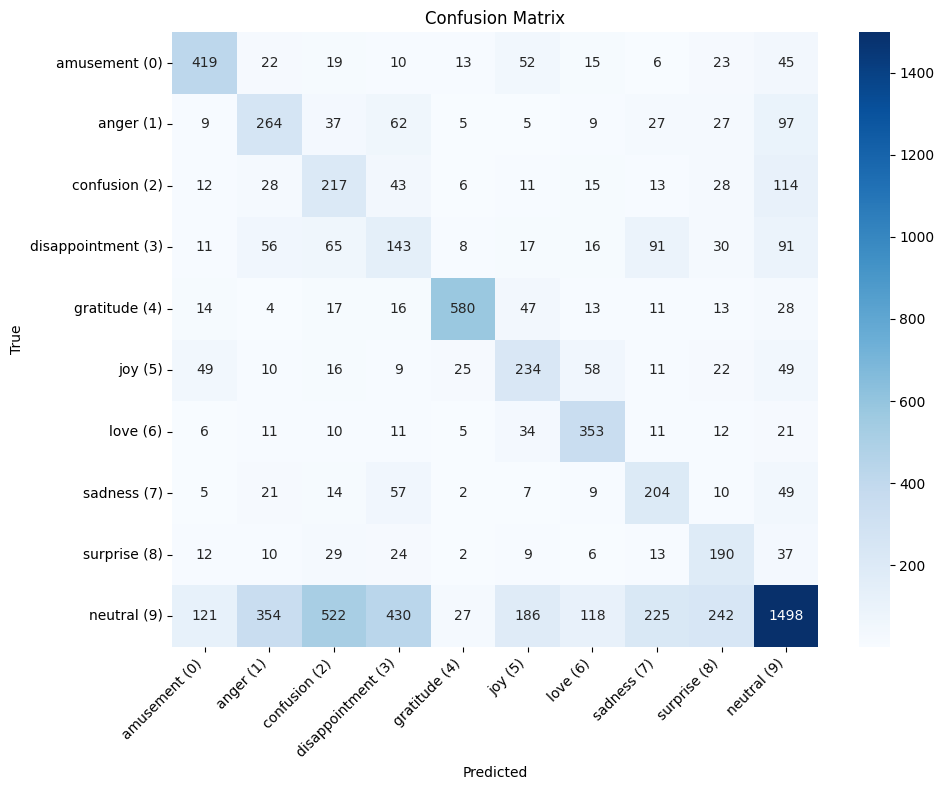

In [114]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred, labels=range(10))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Model Prediction

def predict_emotion(text):

    emotions = [
        "amusement", "anger", "confusion", "disappointment", "gratitude",
        "joy", "love", "sadness", "surprise", "neutral"
    ]
    
    # Clean the text
    text = clean_text(sample_text)
    text_vec = vectorizer.transform([text])
    
    predicted_label = model.predict(text_vec)[0]
    predicted_emotion = emotions[predicted_label]
    
    return predicted_emotion

sample_text = "This is so frustrating!"
predicted_emotion = predict_emotion(sample_text)
print(f"Predicted Emotion: {predicted_emotion}")